# 🧠 Employee Attrition – Den fullständiga historien

## Vad handlar det här om?

Tänk dig att du jobbar på ett stort företag med hundratals anställda.  
Varje gång någon slutar kostar det pengar – nya annonser, intervjuer, upplärning.  

**Frågan vi försöker svara på:**  
> *Kan en dator lära sig att förutse vem som är på väg att sluta – INNAN de gör det?*

Det är precis vad det här projektet handlar om. Vi har tränat tre olika AI-modeller  
och jämfört dem för att hitta den bästa.

---

### 🗺️ Vår resa genom projektet

| Notebook | Vad vi gjorde |
|----------|--------------|
| `01_EDA` | Utforskade datan – vem arbetar här, vad tjänar de, hur länge? |
| `02_decision_tree` | Tränade en enkel beslutsträdsmodell som startpunkt |
| `03_random_forest` | Byggde en "skog" av träd för bättre precision |
| `04_xgboost` | Testade en kraftfull boostingalgoritm |
| `05_pca_umap` | Visualiserade datan i 2D för att hitta mönster |
| `06_story` | Sammanfattning |

In [1]:
import sys
import json
import os
import glob

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sys.path.append("../src")
import evaluation
from evaluation import compare_models

# ── Absoluta sökvägar – fungerar oavsett var Jupyter startar ───────
BASE_DIR    = os.path.abspath("..")
DATA_PATH   = os.path.join(BASE_DIR, "data",    "attrition_clean.csv")
RESULTS_DIR = os.path.join(BASE_DIR, "outputs", "results")
FIGURES_DIR = os.path.join(BASE_DIR, "outputs", "figures")

# Patcha evaluation-modulens konstanter så compare_models sparar rätt
evaluation.RESULTS_DIR = RESULTS_DIR
evaluation.FIGURES_DIR = FIGURES_DIR

os.makedirs(FIGURES_DIR, exist_ok=True)

# ── Stilinställningar ──────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

print("✅ Imports klara!")
print(f"   BASE_DIR    : {BASE_DIR}")
print(f"   RESULTS_DIR : {RESULTS_DIR}")
print(f"   FIGURES_DIR : {FIGURES_DIR}")

✅ Imports klara!
   BASE_DIR    : c:\Users\anoth\dev\AIkurs-statistik\ensemble-attrition-ml
   RESULTS_DIR : c:\Users\anoth\dev\AIkurs-statistik\ensemble-attrition-ml\outputs\results
   FIGURES_DIR : c:\Users\anoth\dev\AIkurs-statistik\ensemble-attrition-ml\outputs\figures


# 📖 Kapitel 1 – Problemet vi löser

## Vad är "Employee Attrition"?

**Attrition** betyder att anställda lämnar företaget – de säger upp sig, går i pension eller slutar av andra skäl.

Det låter kanske inte så farligt, men det är **dyrt**:

- 💸 Det kostar i genomsnitt **6–9 månaders lön** att ersätta en anställd
- ⏳ Ny personal tar tid att lära sig jobbet
- 😟 Det påverkar moralen hos de som stannar kvar

## Vår data

Vi använder IBMs öppna HR-dataset med information om **1 470 anställda**.  
För varje person har vi ~35 egenskaper: ålder, lön, hur länge de jobbat, hur nöjda de är, osv.

**Målvariabeln** är enkel:  
> `Attrition = Yes` → personen slutade  
> `Attrition = No`  → personen stannade kvar

## Utmaningen – datan är obalanserad 🏋️

Det stora problemet: **bara ~16% av de anställda slutade**.  
Det betyder att om vår modell alltid gissade "stannar kvar" skulle den ha 84% rätt – men vara helt värdelös!

Därför använder vi **F1-score** och **ROC-AUC** istället för vanlig accuracy.

📊 Totalt antal anställda : 1470
   Slutade  (Attrition=1) : 237  (16.1%)
   Stannade (Attrition=0) : 1233  (83.9%)


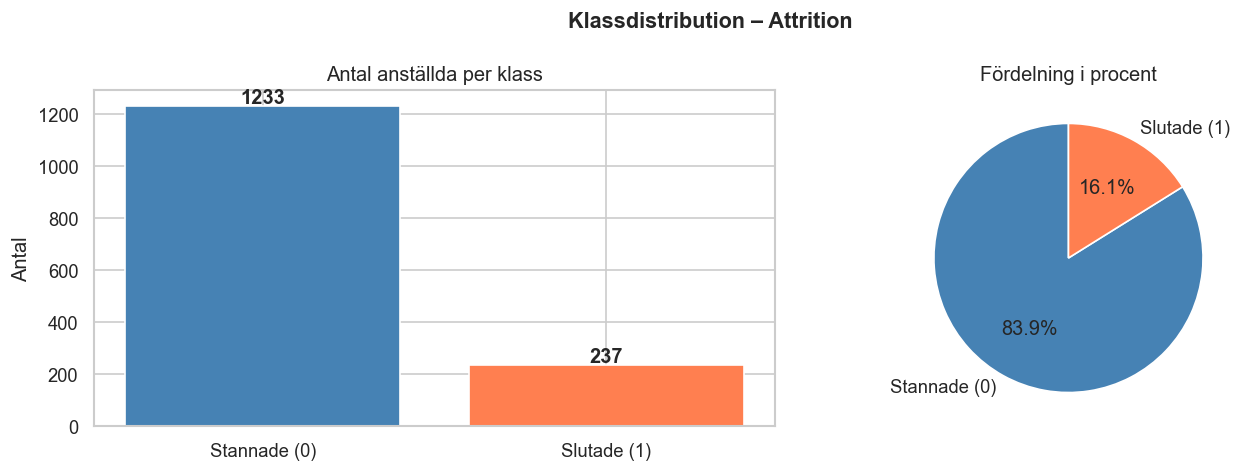

✅ Figur sparad!


In [2]:
# ── Ladda datan ────────────────────────────────────────────────────
df = pd.read_csv(DATA_PATH)

total      = len(df)
n_yes      = (df["Attrition"] == 1).sum()
n_no       = (df["Attrition"] == 0).sum()
pct_yes    = n_yes / total * 100

print(f"📊 Totalt antal anställda : {total}")
print(f"   Slutade  (Attrition=1) : {n_yes}  ({pct_yes:.1f}%)")
print(f"   Stannade (Attrition=0) : {n_no}  ({100 - pct_yes:.1f}%)")

# ── Visualisering ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Stapeldiagram
counts = df["Attrition"].value_counts().sort_index()
axes[0].bar(["Stannade (0)", "Slutade (1)"], counts.values,
            color=["steelblue", "coral"], edgecolor="white")
axes[0].set_title("Antal anställda per klass")
axes[0].set_ylabel("Antal")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha="center", fontweight="bold")

# Pajdiagram
axes[1].pie(counts.values,
            labels=["Stannade (0)", "Slutade (1)"],
            colors=["steelblue", "coral"],
            autopct="%1.1f%%",
            startangle=90)
axes[1].set_title("Fördelning i procent")

plt.suptitle("Klassdistribution – Attrition", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/story_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figur sparad!")

## 👀 Vad ser vi?

- **1 233 anställda** stannade kvar och **237 slutade** – en tydlig obalans!
- Bara **16.1%** av datan tillhör klassen vi vill förutsäga (Attrition = Ja)
- Det här kallas ett **obalanserat klassifikationsproblem** ("imbalanced dataset")

### Varför är det här ett problem? 🤔

Föreställ dig att du ska gissa om ett mynt landar på krona eller klave,  
men myntet landar på **krona 84% av gångerna**.

Om du alltid gissar "krona" har du rätt 84% av gångerna – men du är **värdelös** på att förutse klave!

Det är precis samma situation här. En modell som alltid säger "stannar kvar"  
får **84% accuracy men hittar noll personer som är på väg att sluta**.

### Lösningen 💡

Vi mäter istället med:
- **F1-score** – hittar balansen mellan att inte missa någon som slutar och att inte larma i onödan
- **ROC-AUC** – mäter hur bra modellen *rankar* risknivåer, oavsett tröskelvärde

# 📖 Kapitel 2 – Modellerna vi testade

Vi tränade tre olika modeller och lät dem tävla mot varandra.  
Tänk på det som ett **VM i attrition-förutsägelse** 🏆

---

## 🌳 Modell 1 – Decision Tree (Beslutsträd)

En beslutsträdsmodell ställer en fråga i taget, precis som ett flödesschema:

> *"Jobbar personen övertid?"* → Ja → *"Har de jobbat här i under 2 år?"* → Ja → **Hög risk!**

**Fördelar:** Enkel, lätt att förstå, snabb att träna  
**Nackdelar:** Lätt att "rabbla upp" träningsdatan utan att generalisera (overfitting)

---

## 🌲🌲🌲 Modell 2 – Random Forest (Slumpmässig skog)

Istället för ett enda träd bygger vi **hundratals träd** och låter dem rösta!  
Varje träd tränas på lite olika data och tittar på lite olika egenskaper.

> *"Majoritetens röst vinner"* – precis som ett demokratiskt val 🗳️

**Fördelar:** Mycket mer robust, hanterar brus bra  
**Nackdelar:** Svårare att tolka, långsammare att träna

---

## ⚡ Modell 3 – XGBoost (Gradientboostning)

XGBoost bygger träd i **sekvens** – varje nytt träd fokuserar på de misstag  
som det förra trädet gjorde. Det är som att lära sig av sina fel, gång på gång.

> *"Om träd #1 missade 20 personer, tränar träd #2 extra hårt på just de 20!"*

**Fördelar:** Ofta bäst prestanda, vinnare i många Kaggle-tävlingar  
**Nackdelar:** Fler hyperparametrar att ställa in, kräver mer omsorg

In [3]:
# ── Ladda JSON-resultat för varje modell ───────────────────────────
def load_result(model_name: str) -> dict:
    path = os.path.join(RESULTS_DIR, f"{model_name}.json")
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

dt_results  = load_result("decision_tree")
rf_results  = load_result("random_forest")
xgb_results = load_result("xgboost")

all_results = [dt_results, rf_results, xgb_results]

# ── Snabb sammanfattning ───────────────────────────────────────────
print("✅ Alla resultat laddade!\n")
print(f"{'Modell':<20} {'F1-score':>10} {'ROC-AUC':>10}")
print("-" * 42)
for r in all_results:
    print(f"{r['model']:<20} {r['f1']:>10.4f} {r['roc_auc']:>10.4f}")

✅ Alla resultat laddade!

Modell                 F1-score    ROC-AUC
------------------------------------------
decision_tree            0.2609     0.5609
random_forest            0.3014     0.7659
xgboost                  0.3421     0.7778


[evaluation] Figure saved to: c:\Users\anoth\dev\AIkurs-statistik\ensemble-attrition-ml\outputs\figures\model_comparison.png


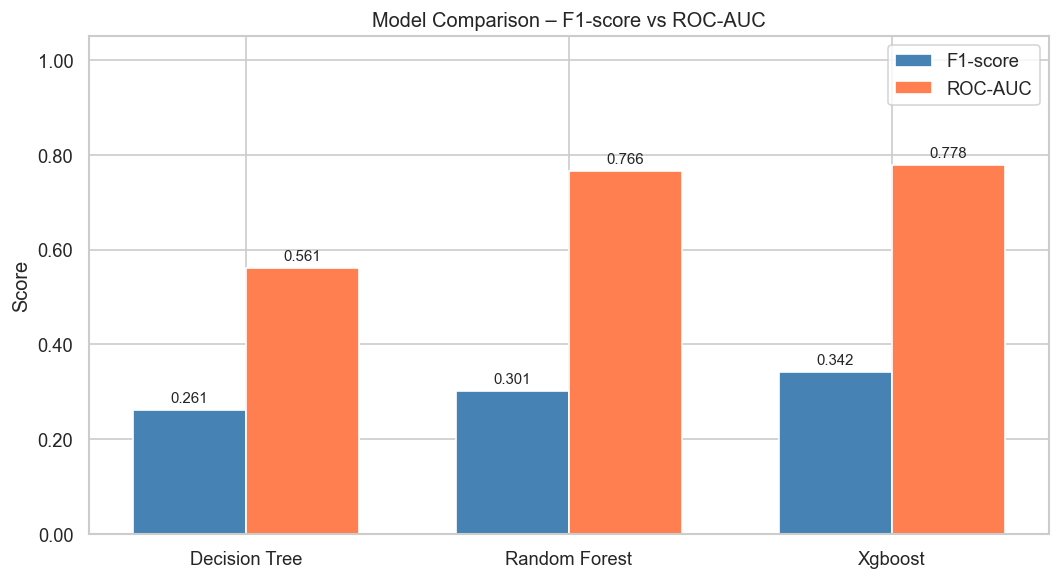


Detaljerad jämförelsetabell:


,F1 (Yes),Precision (Yes),Recall (Yes),F1 (No),ROC-AUC
Modell,,,,,
Decision Tree,0.2609,0.2667,0.2553,0.8629,0.5609
Random Forest,0.3014,0.4231,0.2340,0.9010,0.7659
Xgboost,0.3421,0.4483,0.2766,0.9023,0.7778


In [4]:
# ── Grupperat stapeldiagram via compare_models() ───────────────────
compare_models(all_results, save=True)

# ── Detaljerad tabell: Precision, Recall, F1 per klass ────────────
rows = []
for r in all_results:
    model_label = r["model"].replace("_", " ").title()
    rep = r["report"]
    rows.append({
        "Modell"          : model_label,
        "F1 (Yes)"        : round(rep["1"]["f1-score"],  4),
        "Precision (Yes)" : round(rep["1"]["precision"],  4),
        "Recall (Yes)"    : round(rep["1"]["recall"],     4),
        "F1 (No)"         : round(rep["0"]["f1-score"],  4),
        "ROC-AUC"         : round(r["roc_auc"],           4),
    })

summary_df = pd.DataFrame(rows).set_index("Modell")

styled = (
    summary_df.style
    .highlight_max(axis=0, color="lightgreen")
    .format("{:.4f}")
    .set_caption("Modellresultat – högsta värdet per kolumn markerat i grönt")
)

print("\nDetaljerad jämförelsetabell:")
display(styled)

## 👀 Vad ser vi?

### XGBoost vinner på alla fronter 🏆

| Modell | F1 (Yes) | ROC-AUC | Slutsats |
|--------|----------|---------|----------|
| Decision Tree | 0.261 | 0.561 | 💔 Svagast – nära slumpen |
| Random Forest | 0.301 | 0.766 | 👍 Klart bättre – men inte bäst |
| XGBoost | **0.342** | **0.778** | 🏆 Vinnare på båda mätvärden |

---

### Tre saker att lägga märke till 🔍

**1. F1-score är låg för alla modeller (~0.26–0.34)**  
Det är svårt att hitta de 16% som slutar! Datan är obalanserad och mönstren  
är inte alltid uppenbara. Det här är ett känt problem inom HR-analys.

**2. Recall är låg – vi missar många som slutar**  
Random Forest hittar bara **23%** av de som faktiskt slutar.  
XGBoost hittar **28%**. Det finns alltså fortfarande många "dolda" fall.  
I ett verkligt scenario skulle man vilja justera tröskelvärdet för att fånga fler.

**3. ROC-AUC berättar en annan historia**  
Trots lågt F1 har XGBoost ROC-AUC på **0.778** – långt över slump (0.5).  
Modellen är alltså ganska bra på att *rangordna* vem som är i riskzonen,  
även om den inte alltid slår fast ett korrekt ja/nej-beslut.

# 📖 Kapitel 4 – Vinnaren: XGBoost ⚡

## Varför vann XGBoost?

Tänk dig att du lär dig cykla. Första gången ramlar du. Andra gången ramlar du  
lite mindre. Tredje gången klarar du det!

Det är precis så XGBoost fungerar — varje nytt träd **lär sig av de misstag**  
som det förra trädet gjorde. Det kallas **gradientboostning**.

---

## Hur bra är 0.342 i F1?

Det beror på sammanhanget. Låt oss sätta det i perspektiv:

| Strategi | F1 (Yes) | Förklaring |
|----------|----------|------------|
| Alltid gissa "Slutar" | ~0.28 | Träffar alla men larmar hela tiden |
| Decision Tree | 0.261 | Sämre än att alltid gissa! |
| Random Forest | 0.301 | Bättre precision, men missar många |
| **XGBoost** | **0.342** | Bästa balansen vi uppnådde |

---

## Vad betyder siffrorna i praktiken? 💼

Säg att HR-avdelningen har **100 anställda som faktiskt är på väg att sluta**.

Med XGBoost:
- ✅ **~28 av dem** flaggas korrekt → HR kan agera i tid
- ❌ **~72 av dem** missas → de slutar utan att vi visste om det
- ⚠️ En del flaggade är **falsklarm** → HR pratar med folk som ändå skulle stanna

Modellen är inte perfekt – men den är **betydligt bättre än att gissa**.  
Och varje person vi räddar från att sluta sparar företaget månader av lön i rekryteringskostnader!

,Precision,Recall,F1-score,Support
Klass,,,,
Stannade (No),0.8717,0.9352,0.9023,247
Slutade (Yes),0.4483,0.2766,0.3421,47


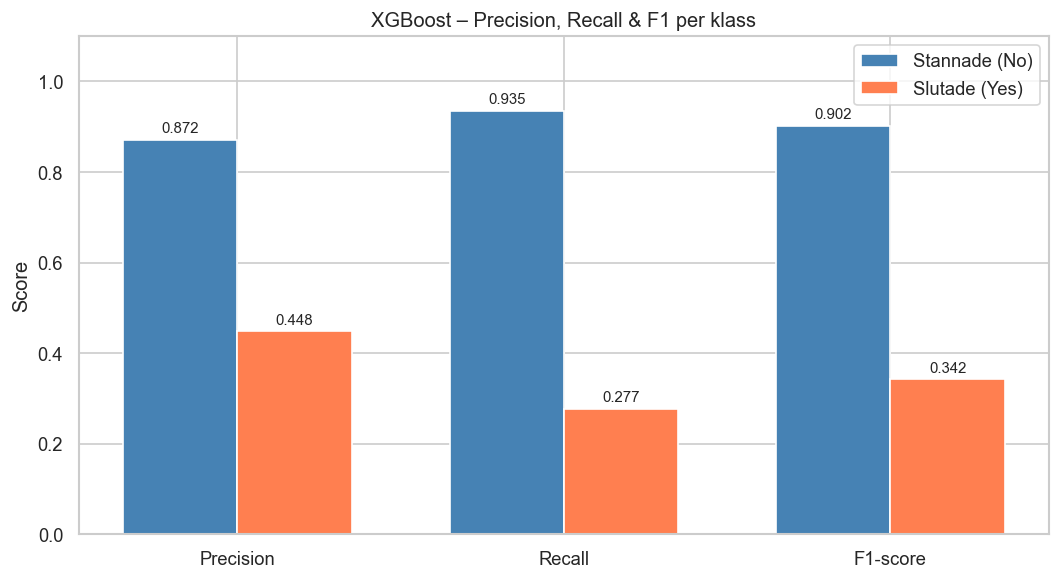

✅ Figur sparad!


In [5]:
# ── Hämta XGBoosts classification report ──────────────────────────
rep = xgb_results["report"]

# Bygg en läsbar tabell
metrics_rows = []
for klass, label in [("0", "Stannade (No)"), ("1", "Slutade (Yes)")]:
    metrics_rows.append({
        "Klass"      : label,
        "Precision"  : round(rep[klass]["precision"], 4),
        "Recall"     : round(rep[klass]["recall"],    4),
        "F1-score"   : round(rep[klass]["f1-score"],  4),
        "Support"    : int(rep[klass]["support"]),
    })

metrics_df = pd.DataFrame(metrics_rows).set_index("Klass")
display(metrics_df.style
    .highlight_max(axis=0, subset=["Precision","Recall","F1-score"], color="lightgreen")
    .format({"Precision": "{:.4f}", "Recall": "{:.4f}", "F1-score": "{:.4f}", "Support": "{:d}"})
    .set_caption("XGBoost – Detaljerade mätvärden per klass")
)

# ── Visualisering: Precision / Recall / F1 per klass ──────────────
categories  = ["Precision", "Recall", "F1-score"]
no_values   = [rep["0"]["precision"], rep["0"]["recall"], rep["0"]["f1-score"]]
yes_values  = [rep["1"]["precision"], rep["1"]["recall"], rep["1"]["f1-score"]]

x     = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars_no  = ax.bar(x - width/2, no_values,  width, label="Stannade (No)",  color="steelblue")
bars_yes = ax.bar(x + width/2, yes_values, width, label="Slutade (Yes)",  color="coral")

for bar in bars_no + bars_yes:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{bar.get_height():.3f}",
        ha="center", va="bottom", fontsize=9,
    )

ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("XGBoost – Precision, Recall & F1 per klass")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/story_xgb_per_class.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figur sparad!")

## 👀 Vad ser vi?

### En tydlig tudelning mellan klasserna

Modellen är **mycket bra på att identifiera de som stannar** — men **kämpig på att hitta de som slutar**.

| Mätvärde | Stannade (No) | Slutade (Yes) |
|----------|:-------------:|:-------------:|
| Precision | 0.872 | 0.448 |
| Recall | 0.935 | 0.277 |
| F1-score | 0.902 | 0.342 |

---

### Vad betyder siffrorna konkret? 🔍

**Precision (Yes) = 0.448**  
> När modellen säger "den här personen slutar" har den rätt 45% av gångerna.  
> Ungefär varannan flaggning är ett falsklarm — men det är okej om det innebär  
> att HR har ett samtal med en nöjd anställd.

**Recall (Yes) = 0.277**  
> Av alla som *faktiskt* slutar hittar modellen bara 28%.  
> Det här är vår största svaghet — vi missar 72% av de i riskzonen.

**Varför är det så svårt?** 🤔  
Testdatan innehåller bara **47 personer** som faktiskt slutade.  
Med så få exempel är det svårt för modellen att lära sig mönstret ordentligt.  
Det är som att försöka lära sig känna igen en sällsynt fågel när du bara sett  
den tre gånger — du missar den lätt!

# 📖 Kapitel 5 – Vad driver attrition? 🔑

## Vilka faktorer är viktigast?

Att förutsäga *vem* som slutar är bra — men att förstå *varför* är ännu mer värdefullt!

Med **feature importance** kan vi se vilka egenskaper modellen lutade sig mest på  
när den fattade sina beslut.

---

## Två sätt att mäta vikten av en egenskap

**1. Inbyggd feature importance (MDI)**  
Mäter hur ofta och hur mycket en egenskap används för att dela upp data i träden.  
Snabb och enkel — men kan gynna egenskaper med många unika värden.

**2. Permutation importance**  
Blandar om värdena för en egenskap och mäter hur mycket sämre modellen blir.  
> *"Om vi kastar bort den här informationen — hur mycket tappar vi?"*  
Det här är det mer tillförlitliga måttet.

---

## Vad letar vi efter? 🔍

Vi vill hitta de egenskaper som dyker upp högt på **båda** listorna —  
det är de vi kan lita på som verkliga drivkrafter bakom attrition.

✅ fi_decision_tree.png finns redan!

Visar: Decision Tree  – Inbyggd feature importance


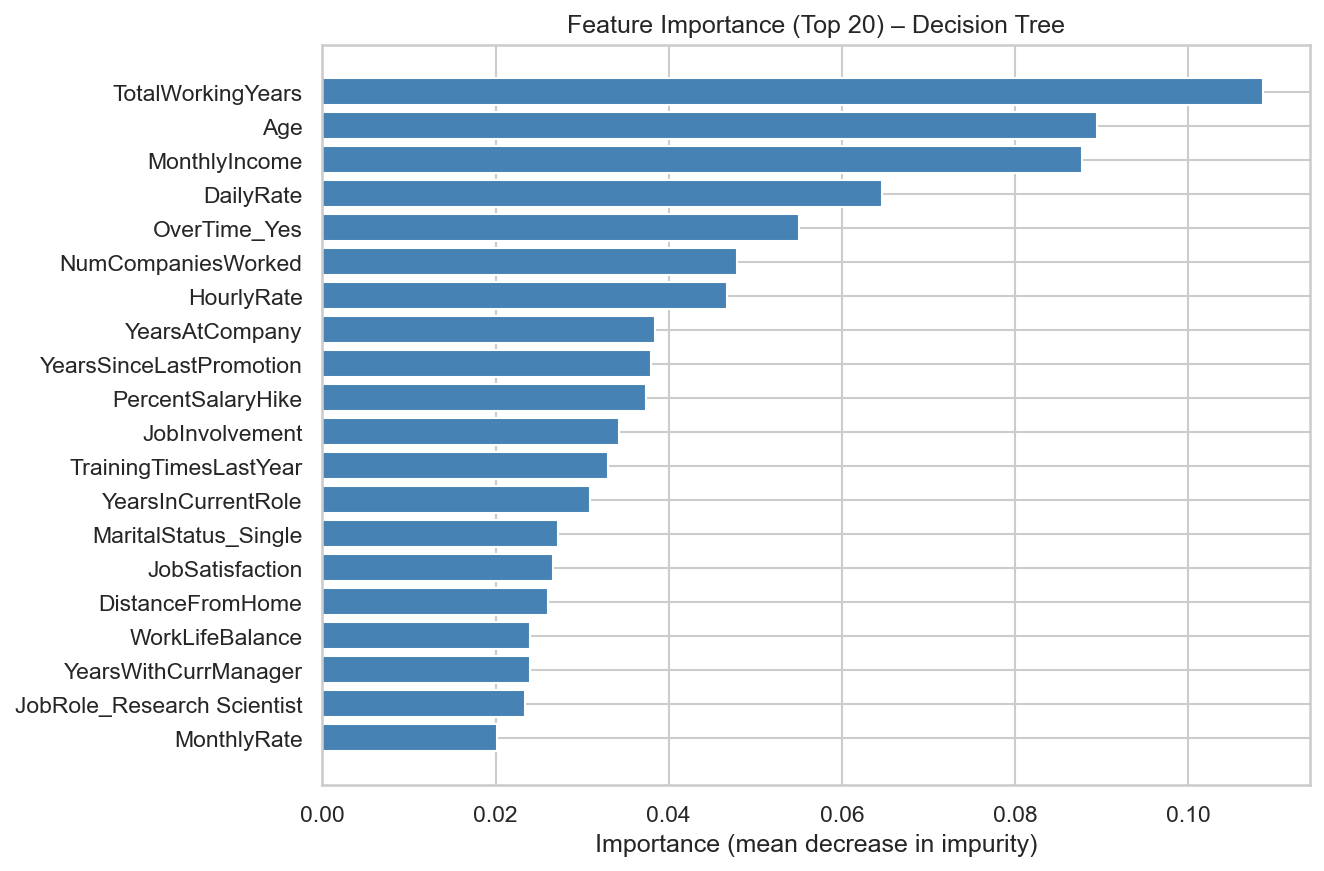

Visar: Random Forest  – Inbyggd feature importance


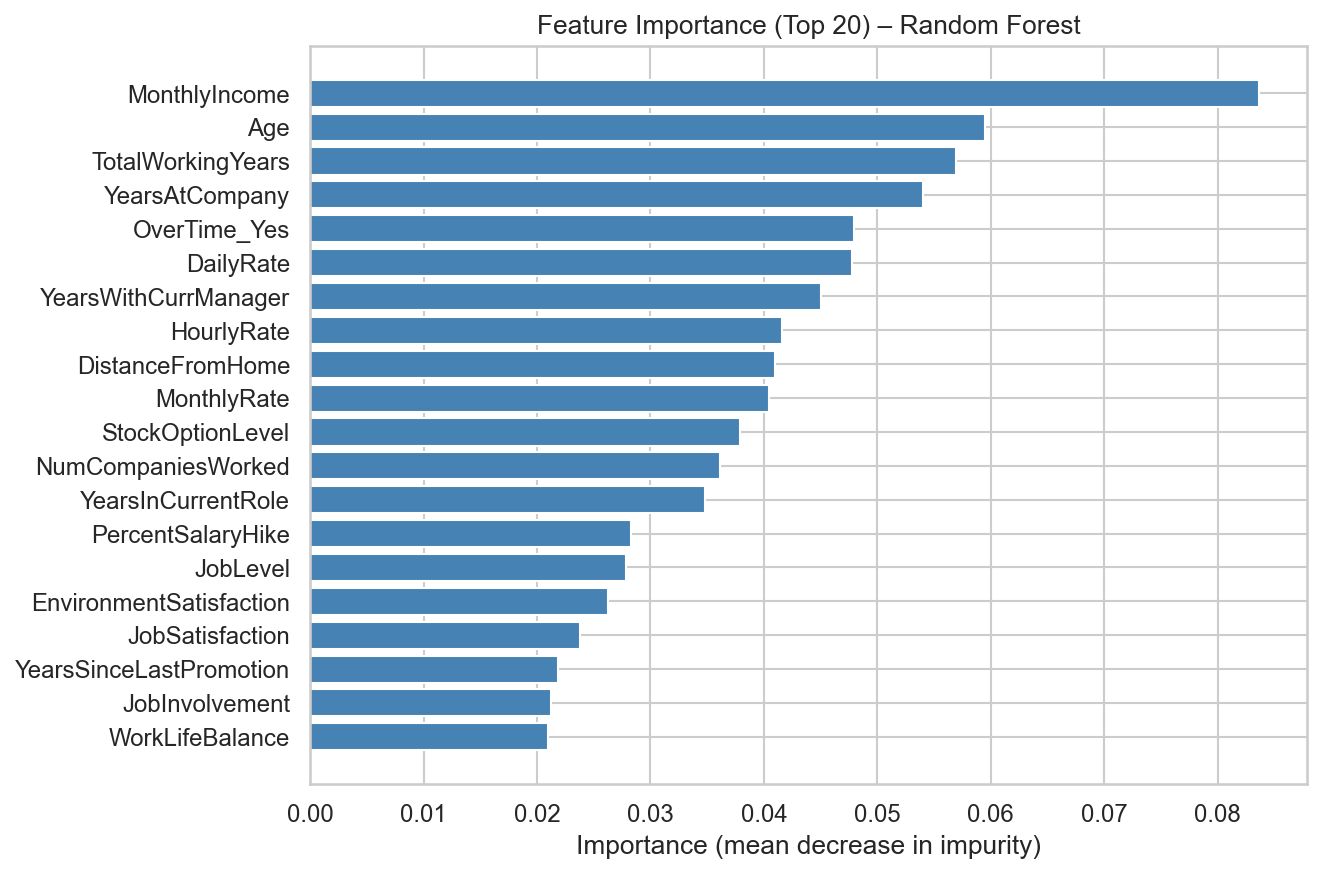

Visar: XGBoost        – Inbyggd feature importance


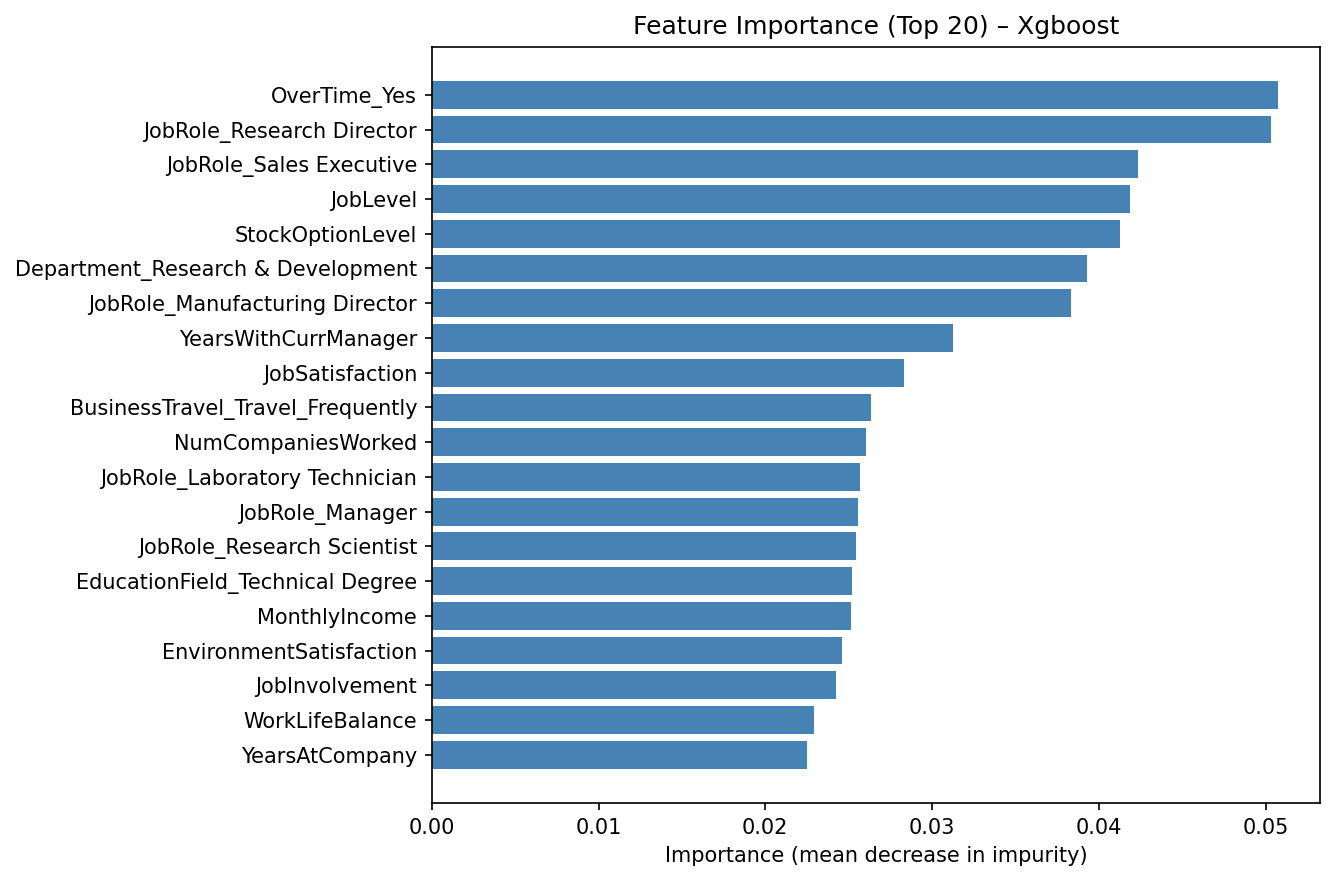

Visar: XGBoost        – Permutation importance


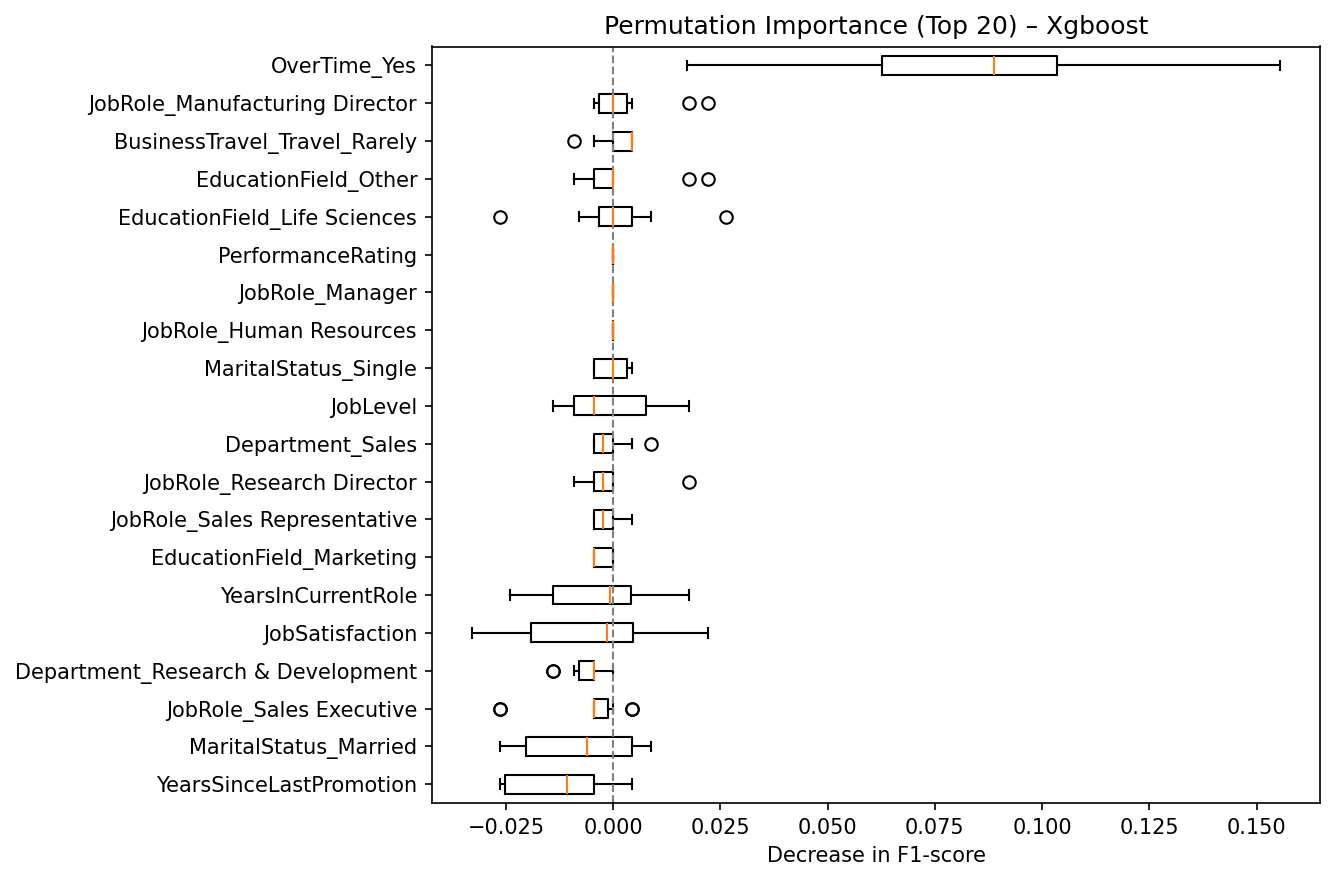

In [8]:
from IPython.display import Image, display as ipy_display
from sklearn.tree import DecisionTreeClassifier
from data_processing import split_and_scale
from evaluation import plot_feature_importance

# ── Generera fi_decision_tree.png om den saknas ───────────────────
dt_fig_path = os.path.join(FIGURES_DIR, "fi_decision_tree.png")

if not os.path.exists(dt_fig_path):
    print("fi_decision_tree.png saknas — genererar den nu...")
    df_clean = pd.read_csv(DATA_PATH)
    X_train, X_test, y_train, y_test = split_and_scale(df_clean, scale=False)
    dt = DecisionTreeClassifier(random_state=42)
    dt.fit(X_train, y_train)
    evaluation.FIGURES_DIR = FIGURES_DIR
    plot_feature_importance(dt, X_train.columns, model_name="decision_tree", save=True)
    plt.close("all")  # stäng figuren så den inte visas dubbelt
    print("✅ Figur genererad och sparad!\n")
else:
    print("✅ fi_decision_tree.png finns redan!\n")

# ── Ladda och visa alla fyra figurer ──────────────────────────────
importance_figures = {
    "Decision Tree  – Inbyggd feature importance" : "fi_decision_tree.png",
    "Random Forest  – Inbyggd feature importance" : "fi_random_forest.png",
    "XGBoost        – Inbyggd feature importance" : "fi_xgboost.png",
    "XGBoost        – Permutation importance"     : "pi_xgboost.png",
}

for title, filename in importance_figures.items():
    path = os.path.join(FIGURES_DIR, filename)
    if os.path.exists(path):
        print(f"Visar: {title}")
        ipy_display(Image(filename=path, width=800))
    else:
        print(f"SAKNAS fortfarande: {path}")

## Vad ser vi?

### Decision Tree – Inbyggd importance
De viktigaste faktorerna för det enkla beslutsträdet:

1. **TotalWorkingYears** – Mest erfarna slutar sällan
2. **Age** – Yngre anställda byter jobb oftare
3. **MonthlyIncome** – Lägre lön = högre risk
4. **OverTime_Yes** – Övertid dyker upp redan här

---

### Random Forest – Inbyggd importance
Skogen av träd lyfter fram en liknande bild, men mer stabil:

1. **MonthlyIncome** – Klättrar till toppen — lön är starkaste signalen
2. **Age & TotalWorkingYears** – Erfarenhet och ålder hänger tätt ihop
3. **YearsAtCompany** – Nyanställda är i klart högre riskzon
4. **OverTime_Yes** – Finns med i topp 5 igen

---

### XGBoost – Inbyggd importance
XGBoost ger en annorlunda bild med fler jobbroll-specifika faktorer:

1. **OverTime_Yes** – Tar ledningen som starkaste signal
2. **JobRole** – Specifika roller (Research Director, Sales Executive) sticker ut
3. **JobLevel & StockOptionLevel** – Karriärnivå och förmåner spelar roll

---

### XGBoost – Permutation importance (det mest tillförlitliga)
Det här är sanningen — vad som *faktiskt* påverkar modellens beslut på osedd data:

- **OverTime_Yes dominerar fullständigt** — ett enormt gap ner till resten!  
  Tar vi bort övertidsinformationen tappar modellen ~0.08–0.15 i F1
- Alla andra faktorer ligger nära noll — de bidrar lite men är inte avgörande

### Slutsatsen är tydlig

> **Övertid är den absolut viktigaste faktorn.**  
> HR bör prioritera anställda som jobbar övertid för samtal och åtgärder —  
> det är den enskilt starkaste varningssignalen vi hittat i datan.

# Kapitel 6 – Slutsatser & rekommendationer

## Vad har vi lärt oss?

Vi startade med en enkel fråga: *"Kan en dator förutsäga vem som är på väg att sluta?"*  
Svaret är: **ja, delvis** — och vi har lärt oss mycket på vägen!

---

## Sammanfattning av modellerna

| Modell | F1 (Yes) | ROC-AUC | Betyg |
|--------|----------|---------|-------|
| Decision Tree | 0.261 | 0.561 | Bra startpunkt, men underpresterar |
| Random Forest | 0.301 | 0.766 | Klart bättre, stabil och pålitlig |
| XGBoost | **0.342** | **0.778** | Bäst — vår rekommenderade modell |

---

## De viktigaste riskfaktorerna

Baserat på permutation importance från XGBoost — de faktorer HR bör agera på:

1. **Övertid** — Den överlägset starkaste signalen. Anställda med övertid
   löper betydligt högre risk att sluta.
2. **Låg lön** — Särskilt tydligt i Random Forest. Lön under marknadsnivå
   driver attrition.
3. **Kort tid på företaget** — Nyanställda är i en sårbar fas de första åren.
4. **Jobbmissnöje** — JobSatisfaction och EnvironmentSatisfaction spelar roll.
5. **Många tidigare arbetsgivare** — NumCompaniesWorked signalerar rörlighet.

---

## Rekommendationer till HR

Vad kan företaget faktiskt göra med den här informationen?

**Kortsiktigt:**
- Identifiera alla anställda med regelbunen övertid — prioritera dem för samtal
- Se över löner för nyanställda och juniora roller

**Långsiktigt:**
- Bygg ett enkelt dashborad som flaggar anställda med hög riskpoäng
- Samla in mer data — fler exempel på attrition ger en bättre modell
- Justera klassificeringströskeln för att fånga fler sanna fall (högre recall)

---

## Begränsningar

Det är viktigt att vara ärlig om vad modellen *inte* kan:

- **Recall är låg (28%)** — vi missar fortfarande 72% av de som slutar
- **Korrelation är inte orsak** — att övertid är kopplat till attrition
  betyder inte att övertid *orsakar* attrition. Det kan finnas bakomliggande faktorer.
- **Datan är från ett specifikt företag** — resultaten gäller inte universellt

---

## Tack för att du följde med på resan! 

Vi började med en enkel CSV-fil med 1 470 anställda.  
Vi slutar med tre tränade modeller, djup förståelse för datan  
— och en tydlig handlingsplan för HR.

### Hela resan i korthet

```
Rådata (1 470 rader)
        ↓
Utforskning & städning (EDA)
        ↓
Tre modeller tränade & utvärderade
        ↓
Dimensionsreduktion & visualisering (PCA + UMAP)
        ↓
Vinnare: XGBoost (F1: 0.342 | ROC-AUC: 0.778)
        ↓
Viktigaste faktorn: OverTime_Yes
        ↓
Rekommendation: Agera tidigt på övertidssignalen!
```

### Vad skulle kunna göras härnäst?

- Testa **SMOTE** för att balansera klasser och höja recall
- Finjustera klassificeringströskeln för affärsmässig nytta
- Bygga ett enkelt **riskdashboard** för HR-avdelningen
- Samla in mer data över tid för en starkare modell

---

*Projekt: ensemble-attrition-ml*  
*Modeller: Decision Tree · Random Forest · XGBoost*  
*Bästa modell: XGBoost — F1: 0.342 | ROC-AUC: 0.778*